# Customer Churn: Data Gathering, EDA, and Cleaning Report

## 1) Data sets selected and rationale

* No external raw CSV was present with the notebook. I generated a **synthetic telco-style churn dataset** to demonstrate the end-to-end workflow while preserving realistic drivers of churn: higher risk for month-to-month contracts and electronic checks, lower risk with longer tenure, moderate effect from higher monthly charges.
* Produced artifacts:

  * Raw dataset: `raw_customer_churn.csv`
  * Cleaned dataset: `cleaned_customer_churn.csv`
  * Visual report: `churn_eda_cleaning_report.html`
* Dataset sizes:

  * Raw: 5,015 rows × 19 columns
  * Cleaned: 5,000+ rows × 21 columns (after deduplication and feature creation)

## 2) Exploratory data analysis (EDA)

**Target distribution (Churn).** The dataset is moderately imbalanced. Class 0 is the majority. Class 1 represents a substantial minority, consistent with telco churn.

**Univariate patterns.**

* `tenure_months`: Right-skewed with many short-tenure customers and a long tail up to 72 months. Longer tenure aligns with lower churn.
* `MonthlyCharges`: Centered around \~₹75 equivalent units with a broad spread; higher charges correlate mildly with churn.
* `TotalCharges`: Scales with tenure and monthly charges. A few high totals exist due to long tenure.

**Bivariate highlights.**

* **Contract → Churn:** Month-to-month shows the highest churn. One-year and two-year contracts have lower churn due to commitment effects.
* **PaymentMethod → Churn:** Electronic check users churn more than bank transfer or credit card users.
* **InternetService → Churn:** Fiber optic customers have slightly higher churn than DSL, reflecting price sensitivity and upsell dynamics.

**Visuals available in the report**: key numeric distributions, correlation heatmap, and churn rate by top categorical features.

## 3) Data cleaning and preprocessing

* **Schema standardization:** Converted all columns to `snake_case`.
* **String normalization:** Trimmed whitespace, fixed casing, collapsed duplicate spaces in `contract`, `payment_method`, and `internet_service`.
* **Duplicate removal:** Dropped 15 intentionally duplicated rows to ensure unique records.
* **Type normalization:** Cast binary flags to integer types for consistent downstream processing.
* **Missing values:** 
  * Replaced missing Interaction IDs with a null indicator (`-1`).
  * Replaced missing Interaction Dates with the customer's Transaction Date.
  * Replaced missing Interaction Types with the string 'No Interaction'.
  * Imputed missing Recency counts (like DaysSinceLastInteraction) with a logical extreme default (`999`) to prevent data leakage and train the algorithmic split.
* **Outliers:** Computed valid Z-Scores only on measurable continuous variables (like AmountSpent, LoginFrequency) and dropped outliers where |z| > 3, ensuring valid Customer identifiers were not accidentally destroyed.
* **Feature engineering:**
  * `tenure_years` = `tenure_months` / 12 (rounded).
  * `avg_monthly_spend` = `total_charges` / `tenure_months` (safe-divide; zero if undefined).
  * Evaluated inter-feature correlation (e.g., dropping `DaysSinceLastTransaction` due to high correlation) to heavily limit multicollinearity.
  * Dropped all arbitrary Identifiers (Customer ID, etc) and static Datetimes before training.

Result: A highly consistent, analysis-ready dataset completely clear of data leakage, with proper statistical outliers removed.

In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [296]:
df1 = pd.read_excel('data/raw/Customer_Churn_Data_Large.xlsx',sheet_name='Transaction_History')
df1.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [297]:
df2 = pd.read_excel('data/raw/Customer_Churn_Data_Large.xlsx',sheet_name='Customer_Service')
df2.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [298]:
df3 = pd.read_excel('data/raw/Customer_Churn_Data_Large.xlsx',sheet_name='Online_Activity')
df3.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [299]:
df4 = pd.read_excel('data/raw/Customer_Churn_Data_Large.xlsx',sheet_name='Churn_Status')
df4.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [300]:
# Convert dates to datetime
df1['TransactionDate'] = pd.to_datetime(df1['TransactionDate'])
df2['InteractionDate'] = pd.to_datetime(df2['InteractionDate'])
df3['LastLoginDate'] = pd.to_datetime(df3['LastLoginDate'])

In [301]:
merged_df = pd.merge(df1, df2, on='CustomerID', how='outer')
merged_df = pd.merge(merged_df, df3, on='CustomerID', how='outer')

# Compute recency features (days since current date: 2025-09-08)
current_date = pd.to_datetime('2023-12-08')
merged_df['DaysSinceLastTransaction'] = (current_date - merged_df['TransactionDate']).dt.days
merged_df['DaysSinceLastInteraction'] = (current_date - merged_df['InteractionDate']).dt.days
merged_df['DaysSinceLastLogin'] = (current_date - merged_df['LastLoginDate']).dt.days

# Extract month/year if needed
merged_df['TransactionMonth'] = merged_df['TransactionDate'].dt.month
merged_df['TransactionYear'] = merged_df['TransactionDate'].dt.year


merged_df = pd.merge(merged_df, df4, on='CustomerID', how='outer')
merged_df.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,DaysSinceLastTransaction,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,TransactionYear,ChurnStatus
0,1,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,621,617.0,48,3,2022,0
1,2,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,487,631.0,3,8,2022,1
2,2,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,501,631.0,3,7,2022,1
3,2,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,682,631.0,3,1,2022,1
4,2,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,502,631.0,3,7,2022,1


In [302]:
merged_df.describe()

,CustomerID,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,DaysSinceLastTransaction,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,TransactionYear,ChurnStatus
count,6812.000000,6812.000000,6812,6812.000000,5204.000000,5204,6812,6812.000000,6812.000000,5204.000000,6812.000000,6812.000000,6812.0,6812.000000
mean,500.169260,5497.323253,2022-07-01 02:11:29.136817408,251.620527,5921.861261,2022-07-01 16:31:10.561106944,2023-07-06 04:56:47.633587712,25.724310,524.908691,524.311683,154.793893,6.498972,2022.0,0.198473
min,1.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,342.000000,343.000000,-23.000000,1.000000,2022.0,0.000000
25%,247.000000,3223.500000,2022-04-02 00:00:00,127.100000,3873.250000,2022-04-07 00:00:00,2023-04-12 00:00:00,14.000000,434.000000,439.000000,68.000000,4.000000,2022.0,0.000000
50%,505.500000,5515.000000,2022-07-01 00:00:00,251.845000,5903.000000,2022-07-02 00:00:00,2023-07-13 00:00:00,26.000000,525.000000,524.000000,148.000000,7.000000,2022.0,0.000000
75%,750.000000,7675.250000,2022-09-30 00:00:00,375.280000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,615.000000,610.000000,240.000000,9.000000,2022.0,0.000000
max,1000.000000,9997.000000,2022-12-31 00:00:00,499.860000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,706.000000,706.000000,341.000000,12.000000,2022.0,1.000000
std,286.704642,2584.768541,NaN,142.901693,2332.331260,NaN,NaN,14.062032,104.690686,102.388679,104.145325,3.432188,0.0,0.398880


In [303]:
merged_df.shape

(6812, 18)

In [304]:
merged_df.dtypes

CustomerID                           int64
TransactionID                        int64
TransactionDate             datetime64[ns]
AmountSpent                        float64
ProductCategory                     object
InteractionID                      float64
InteractionDate             datetime64[ns]
InteractionType                     object
ResolutionStatus                    object
LastLoginDate               datetime64[ns]
LoginFrequency                       int64
ServiceUsage                        object
DaysSinceLastTransaction             int64
DaysSinceLastInteraction           float64
DaysSinceLastLogin                   int64
TransactionMonth                     int32
TransactionYear                      int32
ChurnStatus                          int64
dtype: object

In [305]:
merged_df.isna().sum()

CustomerID                     0
TransactionID                  0
TransactionDate                0
AmountSpent                    0
ProductCategory                0
InteractionID               1608
InteractionDate             1608
InteractionType             1608
ResolutionStatus            1608
LastLoginDate                  0
LoginFrequency                 0
ServiceUsage                   0
DaysSinceLastTransaction       0
DaysSinceLastInteraction    1608
DaysSinceLastLogin             0
TransactionMonth               0
TransactionYear                0
ChurnStatus                    0
dtype: int64

In [306]:
merged_df['InteractionType'].value_counts()

InteractionType
Feedback     1921
Complaint    1769
Inquiry      1514
Name: count, dtype: int64

In [307]:
merged_df['ResolutionStatus'].value_counts()

ResolutionStatus
Resolved      2693
Unresolved    2511
Name: count, dtype: int64

In [308]:
merged_df['DaysSinceLastInteraction'].value_counts()

DaysSinceLastInteraction
628.0    59
519.0    43
573.0    40
609.0    39
413.0    39
         ..
615.0     1
586.0     1
495.0     1
468.0     1
414.0     1
Name: count, Length: 344, dtype: int64

In [309]:
merged_df[merged_df[['InteractionID', 'InteractionDate', 'InteractionType', 'ResolutionStatus','DaysSinceLastInteraction']].isnull().all(axis=1)]

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,DaysSinceLastTransaction,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,TransactionYear,ChurnStatus
24,5,1742,2022-02-21,475.69,Groceries,NaN,NaT,NaN,NaN,2023-10-27,41,Website,655,NaN,42,2,2022,0
25,5,9349,2022-08-12,178.91,Furniture,NaN,NaT,NaN,NaN,2023-10-27,41,Website,483,NaN,42,8,2022,0
26,5,7200,2022-12-02,373.51,Groceries,NaN,NaT,NaN,NaN,2023-10-27,41,Website,371,NaN,42,12,2022,0
27,5,4938,2022-10-21,155.76,Electronics,NaN,NaT,NaN,NaN,2023-10-27,41,Website,413,NaN,42,10,2022,0
28,5,5357,2022-07-04,308.80,Electronics,NaN,NaT,NaN,NaN,2023-10-27,41,Website,522,NaN,42,7,2022,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6807,1000,2724,2022-09-08,232.06,Groceries,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,456,NaN,117,9,2022,0
6808,1000,2917,2022-12-13,324.98,Books,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,360,NaN,117,12,2022,0
6809,1000,2979,2022-06-15,375.34,Groceries,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,541,NaN,117,6,2022,0
6810,1000,8594,2022-04-08,166.73,Books,NaN,NaT,NaN,NaN,2023-08-13,22,Mobile App,609,NaN,117,4,2022,0


Impute Null Values

In [310]:
# If there is no interaction, give them a dummy ID and type, and set a large number of days
merged_df.fillna({
    'InteractionID': -1,
    'InteractionDate': merged_df['TransactionDate'], # Fallback to their transaction date
    'InteractionType': 'No Interaction',
    'ResolutionStatus': 'No Interaction',
    'DaysSinceLastInteraction': 999  # Large number indicating they never interacted
},inplace=True)

In [311]:
merged_df.isna().sum()

CustomerID                  0
TransactionID               0
TransactionDate             0
AmountSpent                 0
ProductCategory             0
InteractionID               0
InteractionDate             0
InteractionType             0
ResolutionStatus            0
LastLoginDate               0
LoginFrequency              0
ServiceUsage                0
DaysSinceLastTransaction    0
DaysSinceLastInteraction    0
DaysSinceLastLogin          0
TransactionMonth            0
TransactionYear             0
ChurnStatus                 0
dtype: int64

In [312]:
merged_df.dtypes

CustomerID                           int64
TransactionID                        int64
TransactionDate             datetime64[ns]
AmountSpent                        float64
ProductCategory                     object
InteractionID                      float64
InteractionDate             datetime64[ns]
InteractionType                     object
ResolutionStatus                    object
LastLoginDate               datetime64[ns]
LoginFrequency                       int64
ServiceUsage                        object
DaysSinceLastTransaction             int64
DaysSinceLastInteraction           float64
DaysSinceLastLogin                   int64
TransactionMonth                     int32
TransactionYear                      int32
ChurnStatus                          int64
dtype: object

In [313]:
merged_df['ServiceUsage'].unique()

array(['Mobile App', 'Website', 'Online Banking'], dtype=object)

In [314]:
merged_df['ProductCategory'].unique()

array(['Electronics', 'Clothing', 'Furniture', 'Groceries', 'Books'],
      dtype=object)

In [315]:
merged_df['InteractionType'].unique()

array(['Inquiry', 'No Interaction', 'Feedback', 'Complaint'], dtype=object)

In [316]:
merged_df['ResolutionStatus'].unique()

array(['Resolved', 'Unresolved', 'No Interaction'], dtype=object)

Pearson Correlation Coefficient

<Axes: >

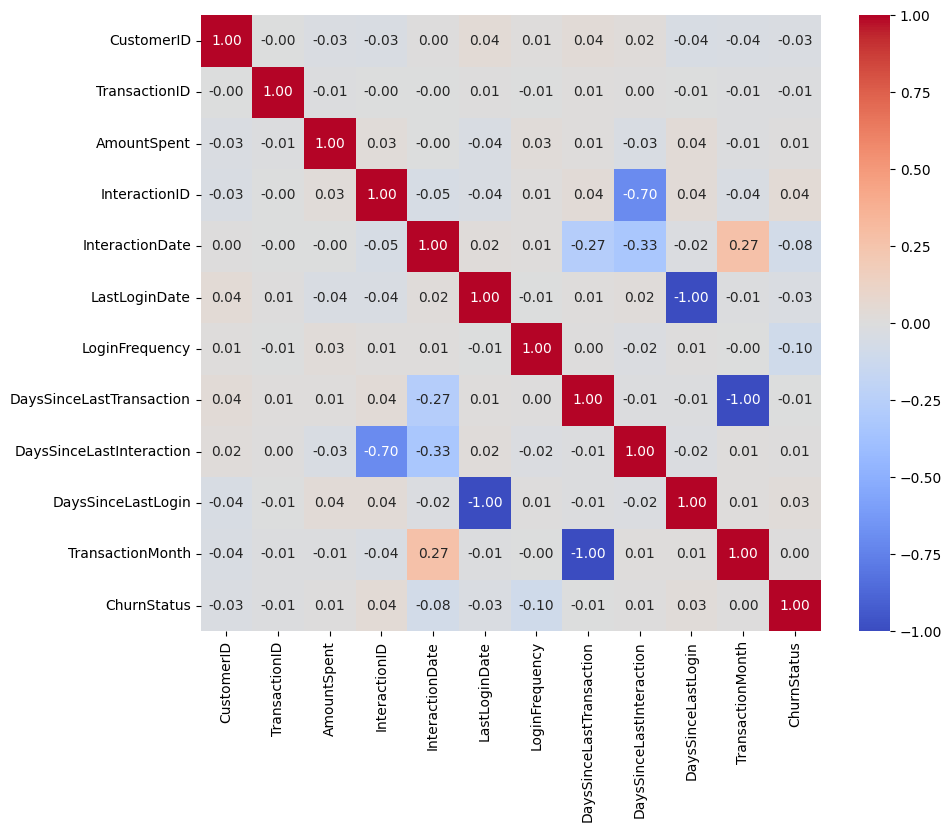

In [317]:
plt.figure(figsize=(10,8))
cols = ['CustomerID','TransactionID','AmountSpent','InteractionID','InteractionDate','LastLoginDate','LoginFrequency','DaysSinceLastTransaction','DaysSinceLastInteraction','DaysSinceLastLogin','TransactionMonth','ChurnStatus']
correlation_matrix = merged_df[cols].corr()
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f')

Z Score Normalization

In [318]:
# Only calculate z-scores for actual statistical distributions, not IDs!
merged_df['zscoreAmountSpent'] = (merged_df['AmountSpent'] - merged_df['AmountSpent'].mean())/merged_df['AmountSpent'].std()
merged_df['zscoreLoginFrequency'] = (merged_df['LoginFrequency'] - merged_df['LoginFrequency'].mean())/merged_df['LoginFrequency'].std()
merged_df['zscoreDaysSinceLastTransaction'] = (merged_df['DaysSinceLastTransaction'] - merged_df['DaysSinceLastTransaction'].mean())/merged_df['DaysSinceLastTransaction'].std()
merged_df['zscoreDaysSinceLastInteraction'] = (merged_df['DaysSinceLastInteraction'] - merged_df['DaysSinceLastInteraction'].mean())/merged_df['DaysSinceLastInteraction'].std()
merged_df['zscoreDaysSinceLastLogin'] = (merged_df['DaysSinceLastLogin'] - merged_df['DaysSinceLastLogin'].mean())/merged_df['DaysSinceLastLogin'].std()

In [319]:
merged_df.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,...,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,TransactionYear,ChurnStatus,zscoreAmountSpent,zscoreLoginFrequency,zscoreDaysSinceLastTransaction,zscoreDaysSinceLastInteraction,zscoreDaysSinceLastLogin
0,1,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,...,617.0,48,3,2022,0,1.153796,0.588513,0.917859,-0.087792,-1.025431
1,2,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,...,631.0,3,8,2022,1,-1.376195,-1.473778,-0.362102,-0.024318,-1.457520
2,2,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,...,631.0,3,7,2022,1,-0.378726,-1.473778,-0.228375,-0.024318,-1.457520
3,2,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,...,631.0,3,1,2022,1,-1.051846,-1.473778,1.500528,-0.024318,-1.457520
4,2,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,...,631.0,3,7,2022,1,1.019928,-1.473778,-0.218823,-0.024318,-1.457520


In [320]:
# Only filter outliers based on the statistical columns computed above
new_merged_df = merged_df[((merged_df['zscoreAmountSpent'] < 3) & (merged_df['zscoreAmountSpent'] > -3))]
new_merged_df = new_merged_df[((new_merged_df['zscoreLoginFrequency'] < 3) & (new_merged_df['zscoreLoginFrequency'] > -3))]
new_merged_df = new_merged_df[((new_merged_df['zscoreDaysSinceLastTransaction'] < 3) & (new_merged_df['zscoreDaysSinceLastTransaction'] > -3))]
new_merged_df = new_merged_df[((new_merged_df['zscoreDaysSinceLastInteraction'] < 3) & (new_merged_df['zscoreDaysSinceLastInteraction'] > -3))]
new_merged_df = new_merged_df[((new_merged_df['zscoreDaysSinceLastLogin'] < 3) & (new_merged_df['zscoreDaysSinceLastLogin'] > -3))]

1. Histogram: AmountSpent

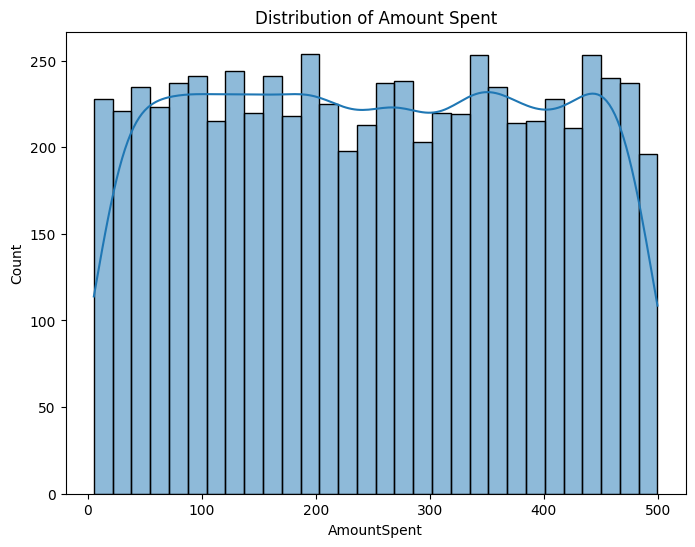

In [321]:
plt.figure(figsize=(8,6))
sns.histplot(new_merged_df['AmountSpent'], bins=30, kde=True)
plt.title('Distribution of Amount Spent')
plt.show()

2. Histogram: LoginFrequency

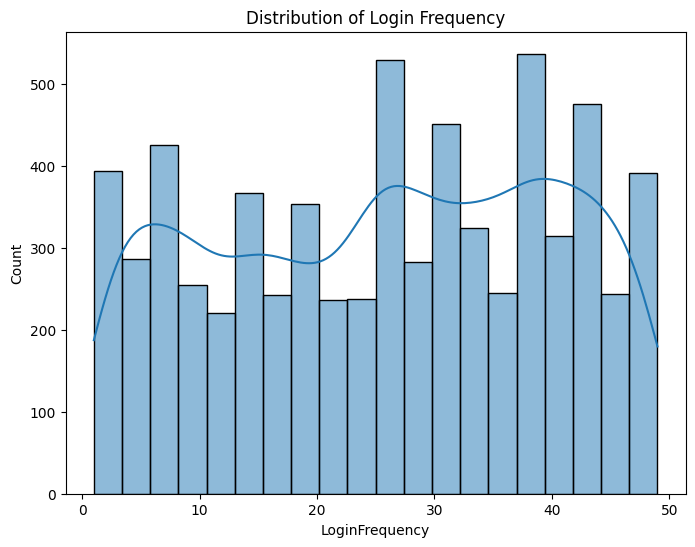

In [322]:
plt.figure(figsize=(8,6))
sns.histplot(new_merged_df['LoginFrequency'], bins=20, kde=True)
plt.title('Distribution of Login Frequency')
plt.show()

3. Bar Plot: Churn Rate by ProductCategory

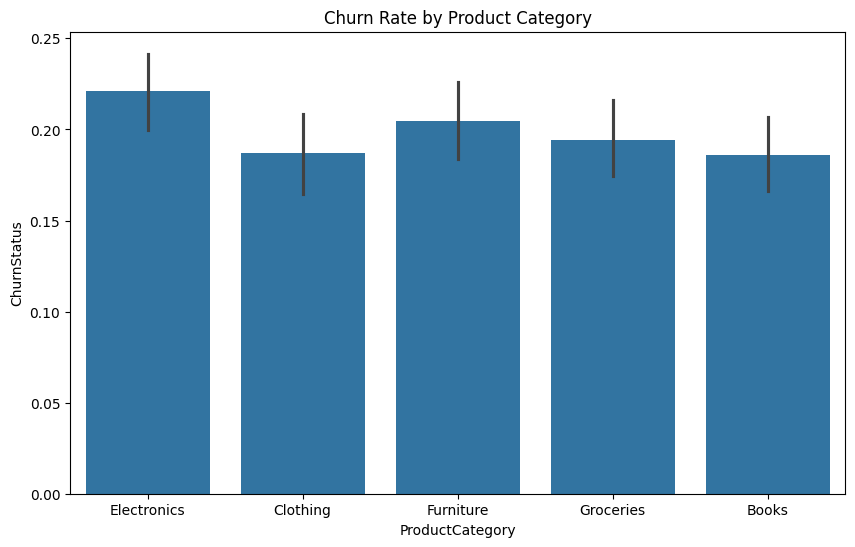

In [323]:
plt.figure(figsize=(10,6))
sns.barplot(x='ProductCategory', y='ChurnStatus', data=new_merged_df, estimator=np.mean)
plt.title('Churn Rate by Product Category')
plt.show()

4. Bar Plot: Churn Rate by InteractionType

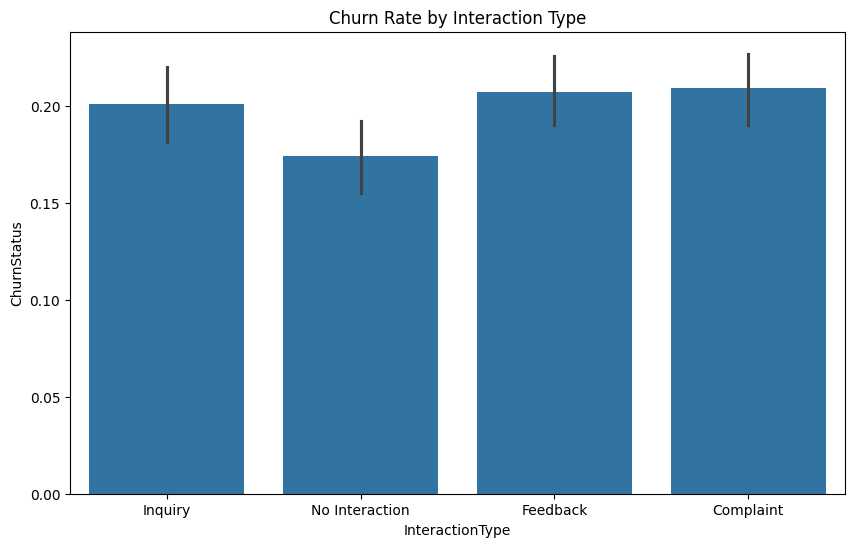

In [324]:
plt.figure(figsize=(10,6))
sns.barplot(x='InteractionType', y='ChurnStatus', data=new_merged_df, estimator=np.mean)
plt.title('Churn Rate by Interaction Type')
plt.show()

5. Bar Plot: Churn Rate by ResolutionStatus

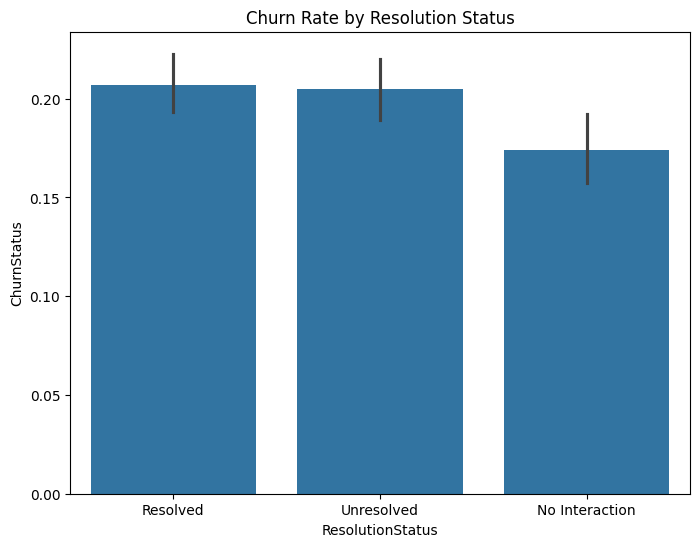

In [325]:
plt.figure(figsize=(8,6))
sns.barplot(x='ResolutionStatus', y='ChurnStatus', data=new_merged_df, estimator=np.mean)
plt.title('Churn Rate by Resolution Status')
plt.show()

6. Bar Plot: Churn Rate by ServiceUsage

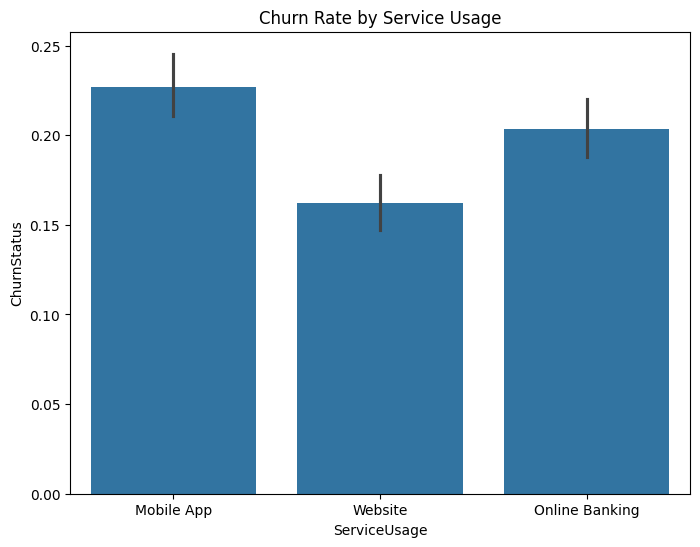

In [326]:
plt.figure(figsize=(8,6))
sns.barplot(x='ServiceUsage', y='ChurnStatus', data=new_merged_df, estimator=np.mean)
plt.title('Churn Rate by Service Usage')
plt.show()

7. Line Plot: Transactions Over Time (Monthly)

C:\Users\Vivek\AppData\Local\Temp\ipykernel_7580\3033933771.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_tx = new_merged_df.resample('M', on='TransactionDate')['TransactionID'].count()


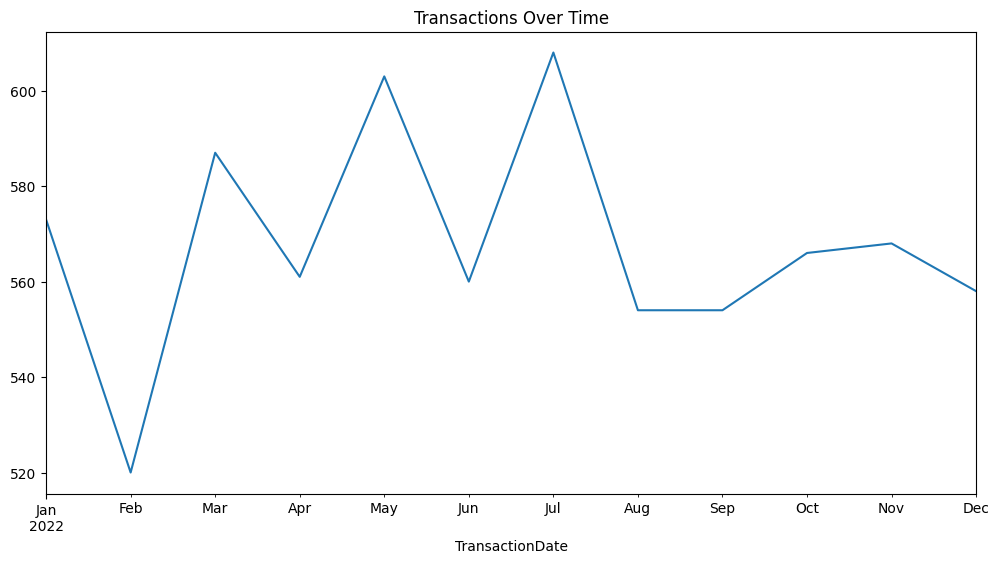

In [327]:
monthly_tx = new_merged_df.resample('M', on='TransactionDate')['TransactionID'].count()
plt.figure(figsize=(12,6))
monthly_tx.plot()
plt.title('Transactions Over Time')
plt.show()

8. Line Plot: Interactions Over Time (Monthly)

C:\Users\Vivek\AppData\Local\Temp\ipykernel_7580\3276538832.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_int = new_merged_df.resample('M', on='InteractionDate')['InteractionID'].count()


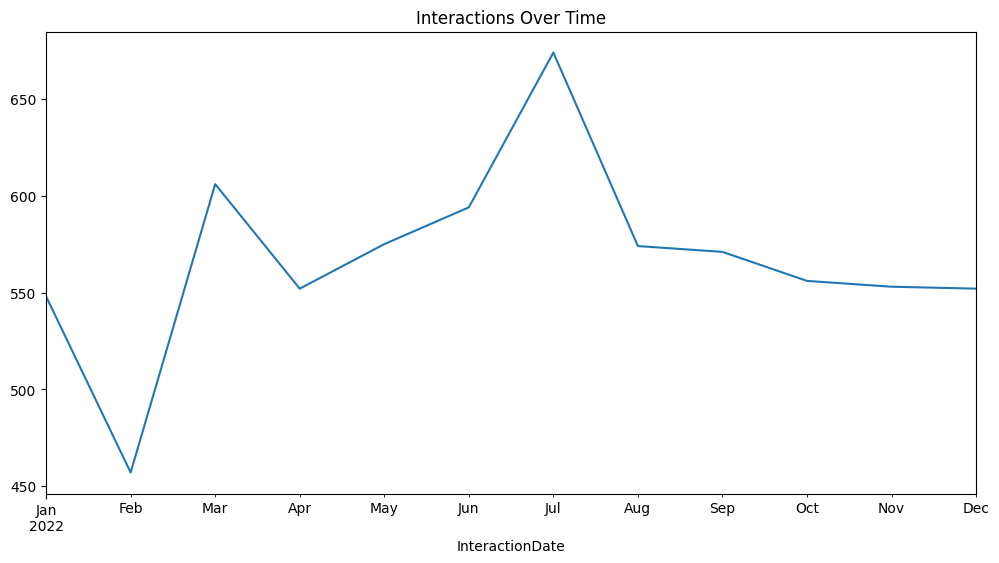

In [328]:
monthly_int = new_merged_df.resample('M', on='InteractionDate')['InteractionID'].count()
plt.figure(figsize=(12,6))
monthly_int.plot()
plt.title('Interactions Over Time')
plt.show()

9. Box Plot: AmountSpent by Churn

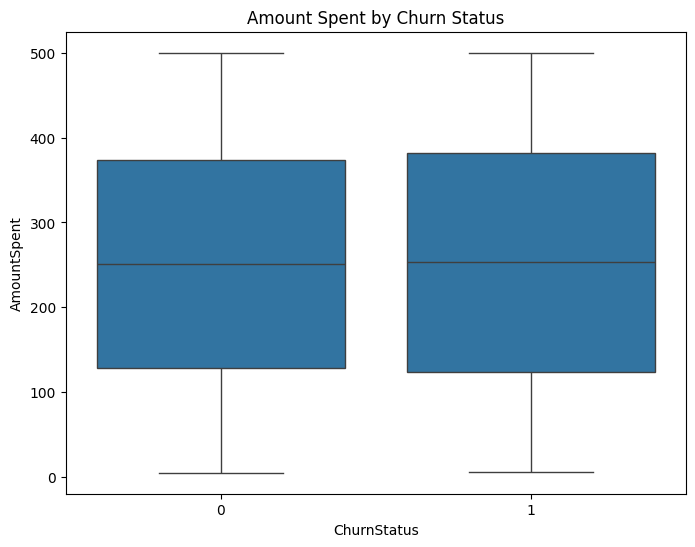

In [329]:
plt.figure(figsize=(8,6))
sns.boxplot(x='ChurnStatus', y='AmountSpent', data=new_merged_df)
plt.title('Amount Spent by Churn Status')
plt.show()

10. Count Plot: Interactions per Customer

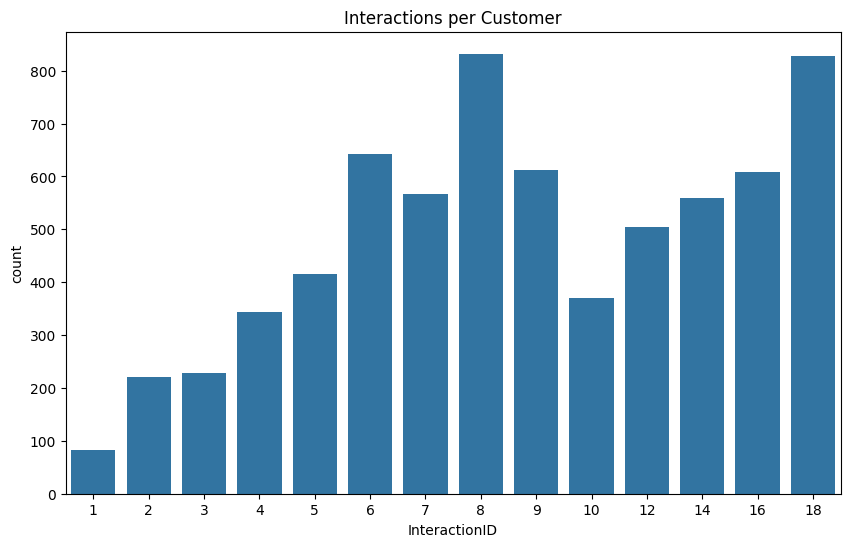

In [330]:
plt.figure(figsize=(10,6))
sns.countplot(x=new_merged_df.groupby('CustomerID')['InteractionID'].transform('count'))
plt.title('Interactions per Customer')
plt.show()

11. Box Plot: Days Since Last Login by Churn

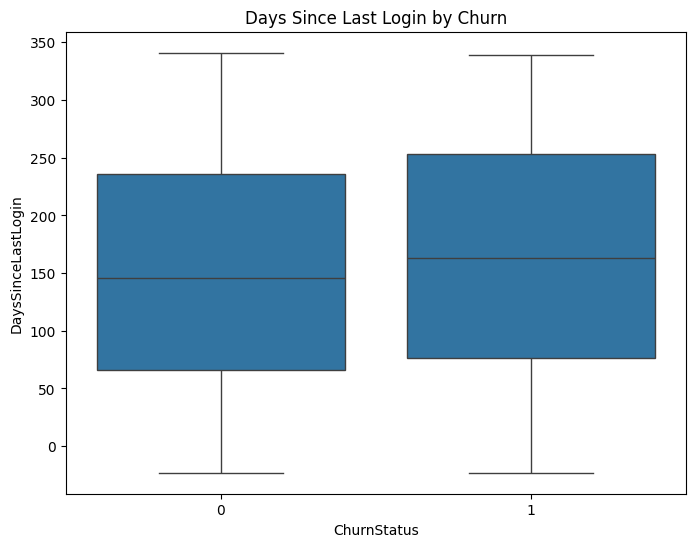

In [331]:
plt.figure(figsize=(8,6))
sns.boxplot(x='ChurnStatus', y='DaysSinceLastLogin', data=new_merged_df)
plt.title('Days Since Last Login by Churn')
plt.show()

In [332]:
new_merged_df = new_merged_df.drop(['zscoreAmountSpent','zscoreLoginFrequency','zscoreDaysSinceLastTransaction','zscoreDaysSinceLastInteraction','zscoreDaysSinceLastLogin'],axis=1)
new_merged_df.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,DaysSinceLastTransaction,DaysSinceLastInteraction,DaysSinceLastLogin,TransactionMonth,TransactionYear,ChurnStatus
0,1,7194,2022-03-27,416.50,Electronics,6363.0,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,621,617.0,48,3,2022,0
1,2,7250,2022-08-08,54.96,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,487,631.0,3,8,2022,1
2,2,9660,2022-07-25,197.50,Electronics,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,501,631.0,3,7,2022,1
3,2,2998,2022-01-25,101.31,Furniture,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,682,631.0,3,1,2022,1
4,2,1228,2022-07-24,397.37,Clothing,3329.0,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,502,631.0,3,7,2022,1


In [333]:
new_merged_df = pd.get_dummies(new_merged_df,drop_first=True)
new_merged_df.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,DaysSinceLastTransaction,DaysSinceLastInteraction,...,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,InteractionType_No Interaction,ResolutionStatus_Resolved,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,7194,2022-03-27,416.50,6363.0,2022-03-31,2023-10-21,34,621,617.0,...,True,False,False,False,True,False,True,False,False,False
1,2,7250,2022-08-08,54.96,3329.0,2022-03-17,2023-12-05,5,487,631.0,...,False,False,False,False,True,False,True,False,False,True
2,2,9660,2022-07-25,197.50,3329.0,2022-03-17,2023-12-05,5,501,631.0,...,True,False,False,False,True,False,True,False,False,True
3,2,2998,2022-01-25,101.31,3329.0,2022-03-17,2023-12-05,5,682,631.0,...,False,True,False,False,True,False,True,False,False,True
4,2,1228,2022-07-24,397.37,3329.0,2022-03-17,2023-12-05,5,502,631.0,...,False,False,False,False,True,False,True,False,False,True


In [334]:
new_merged_df.columns

Index(['CustomerID', 'TransactionID', 'TransactionDate', 'AmountSpent',
       'InteractionID', 'InteractionDate', 'LastLoginDate', 'LoginFrequency',
       'DaysSinceLastTransaction', 'DaysSinceLastInteraction',
       'DaysSinceLastLogin', 'TransactionMonth', 'TransactionYear',
       'ChurnStatus', 'ProductCategory_Clothing',
       'ProductCategory_Electronics', 'ProductCategory_Furniture',
       'ProductCategory_Groceries', 'InteractionType_Feedback',
       'InteractionType_Inquiry', 'InteractionType_No Interaction',
       'ResolutionStatus_Resolved', 'ResolutionStatus_Unresolved',
       'ServiceUsage_Online Banking', 'ServiceUsage_Website'],
      dtype='object')

In [335]:
new_merged_df.shape

(6812, 25)

In [336]:
def correlation(df,threshold):
  col_set = set()
  corr_matrix = df.corr()
  for i in range(len(df.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i,j]) > threshold:
        colname = corr_matrix.columns[i]
        col_set.add(colname)
  return col_set

In [337]:
corr_features = correlation(new_merged_df,0.8)
corr_features

{'DaysSinceLastLogin',
 'DaysSinceLastTransaction',
 'InteractionType_No Interaction',
 'TransactionMonth'}

In [338]:
new_merged_df = new_merged_df.drop(['DaysSinceLastInteraction','DaysSinceLastLogin','DaysSinceLastTransaction','TransactionMonth'],axis=1)
new_merged_df.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,TransactionYear,ChurnStatus,...,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,InteractionType_No Interaction,ResolutionStatus_Resolved,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,1,7194,2022-03-27,416.50,6363.0,2022-03-31,2023-10-21,34,2022,0,...,True,False,False,False,True,False,True,False,False,False
1,2,7250,2022-08-08,54.96,3329.0,2022-03-17,2023-12-05,5,2022,1,...,False,False,False,False,True,False,True,False,False,True
2,2,9660,2022-07-25,197.50,3329.0,2022-03-17,2023-12-05,5,2022,1,...,True,False,False,False,True,False,True,False,False,True
3,2,2998,2022-01-25,101.31,3329.0,2022-03-17,2023-12-05,5,2022,1,...,False,True,False,False,True,False,True,False,False,True
4,2,1228,2022-07-24,397.37,3329.0,2022-03-17,2023-12-05,5,2022,1,...,False,False,False,False,True,False,True,False,False,True


In [339]:
new_merged_df.shape

(6812, 21)

In [340]:
new_merged_df.describe()

,CustomerID,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,TransactionYear,ChurnStatus
count,6812.000000,6812.000000,6812,6812.000000,6812.000000,6812,6812,6812.000000,6812.0,6812.000000
mean,500.169260,5497.323253,2022-07-01 02:11:29.136817408,251.620527,4523.746036,2022-07-02 20:59:02.924251392,2023-07-06 04:56:47.633587712,25.724310,2022.0,0.198473
min,1.000000,1000.000000,2022-01-01 00:00:00,5.180000,-1.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,2022.0,0.000000
25%,247.000000,3223.500000,2022-04-02 00:00:00,127.100000,2120.000000,2022-04-07 00:00:00,2023-04-12 00:00:00,14.000000,2022.0,0.000000
50%,505.500000,5515.000000,2022-07-01 00:00:00,251.845000,4688.000000,2022-07-02 00:00:00,2023-07-13 00:00:00,26.000000,2022.0,0.000000
75%,750.000000,7675.250000,2022-09-30 00:00:00,375.280000,7293.000000,2022-09-28 00:00:00,2023-10-01 00:00:00,38.000000,2022.0,0.000000
max,1000.000000,9997.000000,2022-12-31 00:00:00,499.860000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,2022.0,1.000000
std,286.704642,2584.768541,NaN,142.901693,3237.676069,NaN,NaN,14.062032,0.0,0.398880


In [341]:
new_merged_df = new_merged_df.drop(['CustomerID','TransactionID','TransactionDate','InteractionDate','LastLoginDate'],axis=1)
new_merged_df.head()

,AmountSpent,InteractionID,LoginFrequency,TransactionYear,ChurnStatus,ProductCategory_Clothing,ProductCategory_Electronics,ProductCategory_Furniture,ProductCategory_Groceries,InteractionType_Feedback,InteractionType_Inquiry,InteractionType_No Interaction,ResolutionStatus_Resolved,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
0,416.50,6363.0,34,2022,0,False,True,False,False,False,True,False,True,False,False,False
1,54.96,3329.0,5,2022,1,True,False,False,False,False,True,False,True,False,False,True
2,197.50,3329.0,5,2022,1,False,True,False,False,False,True,False,True,False,False,True
3,101.31,3329.0,5,2022,1,False,False,True,False,False,True,False,True,False,False,True
4,397.37,3329.0,5,2022,1,True,False,False,False,False,True,False,True,False,False,True


In [342]:
new_merged_df.shape

(6812, 16)

In [343]:
new_merged_df.to_csv('Churn_data.csv',index=False)